# Emerging Technologies Assessment

# Introduction
The following notebook examines and demonstrates the **Deutsch-Jozsa Algorithm**, one of the earliest examples of a quantum algorithm outperforming its classical counterpart 

The Deutsch-Jozsa Algorithm is a quantum algorithm that determines whether (in this case) a Boolean function is either **constant** or **balanced** with just a single query to the function. Comparing this to classical computing where it requires $2^{n-1} + 1$ queries in the worst case for a function with $n$ input bits.

For example in classical computing for a 4-input function, the worst case is 9 queries. But for the Deutsch–Jozsa algorithm it can do it in 1.

This advantage comes from two key quantum phenomena:
- **Superposition** — a qubit can exist in both states ($|0\rangle$ and $|1\rangle$) simultaneously until measured. This allows the algorithm to evaluate the function on all inputs at once, rather than one at a time.
- **Interference** — quantum states can interact with each other, enhancing the probability of correct outcomes while cancelling out incorrect ones. The algorithm is structured so this interference directly reveals whether the function is constant or balanced.

## Notebook overview:
| Problem | Topic |
|---------|-------|
| 1 | Generating random constant and balanced Boolean functions |
| 2 | Determining function type classically, and analysing the cost |
| 3 | Building quantum oracles for single-input Boolean functions |
| 4 | Implementing Deutsch's algorithm in Qiskit |
| 5 | Scaling up to the full Deutsch–Jozsa algorithm for 4-input functions |

# Imports


In [1]:
# Used to generate random numbers for the boolean functions
import random

# Quantum computing libraries for building and simulating quantum circuits
import qiskit
import qiskit_aer as aer

# Used for saving circuit diagrams as images
import matplotlib
import matplotlib.pyplot as plt

# Ensure the image output folder exists
import os
os.makedirs('img', exist_ok=True)

print("All necessary libraries have been imported successfully.")

All necessary libraries have been imported successfully.


## Problem 1: Generating Random Boolean Functions
### Context
The [Deutsch–Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) works with a specific type of function: one that takes Boolean inputs and returns a single Boolean output. Each function is guaranteed to be either **constant** or **balanced**.

### Boolean Functions
A [Boolean function](https://realpython.com/python-boolean/) takes `True`/`False` inputs and returns a single `True`/`False` output. In this problem, we work with functions that take **four** Boolean inputs, giving $2^4 = 16$ possible input combinations.

### Constant vs Balanced

| Type | Meaning |
|---|---|
| **Constant** | Returns the same value (`True` or `False`) for all 16 inputs |
| **Balanced** | Returns `True` for exactly 8 inputs, `False` for the other 8 |

There are exactly **2 constant functions** (always-True and always-False). There are $\binom{16}{8} = 12{,}870$ different balanced functions.

The Deutsch–Jozsa algorithm can identify which type a function is using just 1 quantum query, whereas classically we may need up to 9 queries for a 4-input function.

### Truth Tables
A **truth table** is a simple way to represent a Boolean function. It lists all possible inputs and their outputs.

For our 4-input function, we store the truth table as a list of 16 values:

```python
truth_table = [True, False, True, True, False, ..., False]
              # index 0    1      2     3     4         15
```

To look up the output for a given input, we convert the 4 Boolean inputs into a number from 0 to 15 using **bit shifting**:

```python
index = (a << 3) | (b << 2) | (c << 1) | d
```

This converts each Boolean input (True=1, False=0) into a single index. For example, inputs `(True, False, True, False)` become index 10.

Then we simply return `truth_table[index]` to get the output.

### Implementation

The function `random_constant_balanced()` will randomly produce either a constant or a balanced Boolean function. This will serve as the test data generator for the rest of the problems.

Approach:
1. Randomly decide: will this be a constant or balanced function?
2. Build a truth table (list of 16 Boolean values):
   - If constant: all 16 values are the same
   - If balanced: 8 values are `True`, 8 are `False` (shuffled randomly)
3. Create a function that converts inputs to an index and looks up the answer in the truth table
4. Attach metadata to the function so we can inspect what type was created

In [2]:
def random_constant_balanced():
    """
    Returns a randomly chosen Boolean function that is either constant or balanced.

    The returned function takes four Boolean arguments (a, b, c, d)
    and returns a single Boolean output.

    - Constant: always returns the same value for all 16 inputs.
    - Balanced: returns True for exactly 8 of the 16 inputs.

    Returns:
        A callable f(a, b, c, d) -> bool with attached metadata.
    """
    # Choose randomly between 'constant' and 'balanced'
    is_constant = random.choice([True, False])

    # Build the truth table for the function
    if is_constant:
        # Constant if all 16 outputs are the same
        output_value = random.choice([True, False])
        truth_table = [output_value] * 16
    else:
        # Balanced: 8 True and 8 False outputs
        truth_table = [True] * 8 + [False] * 8
        random.shuffle(truth_table)  # Shuffle to randomize the order

    # Function to use the truth table
    def f(a, b, c, d):
        """
        Evaluate the function for inputs (a, b, c, d).
        Converts inputs to an index and looks up the answer.
        """
        # Convert 4 boolean inputs to an index (0-15)
        index = (a << 3) | (b << 2) | (c << 1) | d
        return truth_table[index]
        
    # Attach metadata to the function
    f.truth_table = truth_table
    f.is_constant = is_constant
    
    return f

### Code Explanation

The function randomly creates either a **constant** or **balanced** function.

It starts by flipping a coin to decide which type to create, then builds a truth table, a list of 16 Boolean values.

For a **constant** function, all 16 values are the same (either all `True` or all `False`). For a **balanced** function, it starts with 8 `True` and 8 `False` values and shuffles them.

The inner function `f(a, b, c, d)` converts the four Boolean inputs into an index (0–15) using bit shifting, then looks up the result in the truth table.

The truth table and a flag for whether the function is constant are attached to `f` as metadata, so we can inspect them after the fact.

### Testing
Verify if the function works by evaluating it on all 16 inputs, and checking whether it is constant (all outputs being the same) or balanced (8 True, 8 False).

In [3]:
# Generate a random Boolean function
f = random_constant_balanced()

# Test with all 16 combinations of 4-bit inputs
print("Testing the function on all 16 4-bit inputs:\n")
print("Input (a, b, c, d) → Output")
print("-" * 40)

outputs = []
for a in [False, True]:
    for b in [False, True]:
        for c in [False, True]:
            for d in [False, True]:
                result = f(a, b, c, d)
                outputs.append(result)
                
                # Output as binary 1 for True and 0 for False
                binary_output = f"{int(a)}{int(b)}{int(c)}{int(d)}"
                print(f"{binary_output} = {result}")

Testing the function on all 16 4-bit inputs:

Input (a, b, c, d) → Output
----------------------------------------
0000 = False
0001 = True
0010 = True
0011 = False
0100 = False
0101 = True
0110 = True
0111 = False
1000 = True
1001 = True
1010 = False
1011 = False
1100 = True
1101 = True
1110 = False
1111 = False


In [4]:
# Check the True outputs to verify if the function is correct
true_count = sum(outputs)
false_count = len(outputs) - true_count

print(f"\nTrue outputs: {true_count}")
print(f"False outputs: {false_count}")
print(f"\nFunction type: ", end="")

if f.is_constant:
    print(f"Constant (always returns {f.truth_table[0]})")
    # Verify all outputs are the same
    assert len(set(outputs)) == 1, "Error: constant function should return same value for all inputs"
    print("Verified: All outputs are the same")
else:
    print("Balanced (returns True for exactly 8 inputs and False for 8 inputs)")
    # Verify there are exactly 8 True and 8 False outputs
    assert true_count == 8, "Error: balanced function should return True for exactly 8 inputs"
    print("Verified: Exactly 8 True and 8 False outputs")


True outputs: 8
False outputs: 8

Function type: Balanced (returns True for exactly 8 inputs and False for 8 inputs)
Verified: Exactly 8 True and 8 False outputs


### Code Explanation

To verify the function works, we test it on all 16 possible input combinations using nested loops. For each combination we call `f` and store the result, printing it in binary notation so it's easy to read.

After all 16 inputs we count the `True` and `False` outputs and check they match the expected type, if constant all 16 should be the same, if balanced we should see exactly 8 each. The assertions will catch anything unexpected.

## Problem 2: Classical Testing for Function Type
### Context
Deutsch's algorithm is designed to demonstrate a [potential advantage of quantum computing](https://www.quantamagazine.org/john-preskill-explains-quantum-supremacy-20191002/) compared to classical computation. We need to find out and understand the classical cost of solving this problem, so we can find out the advantage it gives.

In Problem 1, we generated random Boolean functions that are guaranteed to be either constant or balanced. We need to write a function that can **determine which type a given function is** by calling it and analysing the results.

### The Classical Problem
Given a function `f(a, b, c, d)` that takes 4 Boolean inputs and returns 1 Boolean output, we know it is either:
- **Constant**: returns the same value for all 16 possible input combinations
- **Balanced**: returns `True` for exactly 8 inputs and `False` for the other 8

The objective is to determine which type it is by calling the function and examining the results.

### Query Complexity
To determine whether a Boolean function is constant or balanced **with certainty**, we need to understand the theoretical bounds on how many function calls (queries) are required.

With 16 possible inputs:
- A **constant** function returns the same value for all 16 inputs
- A **balanced** function returns `True` for exactly 8 inputs and `False` for exactly 8 inputs

### Implementation
The function `determine_constant_balanced(f)` takes a function `f` as an input and determines whether it is constant or balanced.

#### Approach
1. Call the function `f` with different Boolean input combinations
2. Store the results we get
3. As soon as we see **both** `True` and `False` outputs, we know it is **balanced**
4. If we call all 16 combinations and see only one value, it is **constant**
5. Return the result as a string: `"constant"` or `"balanced"`

In [5]:
def determine_constant_balanced(f):
    """
    Determines whether the given Boolean function f is constant or balanced.

    Args:
        f: A Boolean function that takes four Boolean arguments (a, b, c, d) and returns a Boolean output.

    Returns:
        A string indicating whether the function is "constant" or "balanced".
    """
    # Store results when calling f
    results = []

    # Iterate through all 16 combinations of inputs (a, b, c, d)
    for a in [False, True]:
        for b in [False, True]:
            for c in [False, True]:
                for d in [False, True]:
                    result = f(a, b, c, d)
                    results.append(result)

    # Count the number of True and False results
    true_count = results.count(True)
    false_count = results.count(False)

    # Determine if the function is constant or balanced
    if true_count == 0 or false_count == 0:
        return "constant"
    else:
        return "balanced"

### Code Explanation

This works by calling `f` on all 16 input combinations and recording the results. It then counts how many outputs are `True` and how many are `False`.

If all outputs are the same value, the function is constant. If there's a mix, it must be balanced, since we know balanced functions return exactly 8 `True` and 8 `False`.

In the worst case we need all 16 queries to be certain, but in practice we could stop early once we've seen both values.

### Efficiency Note

Our implementation always makes **16 function calls**, but that's more than strictly necessary.

**Theoretical worst case is 9 queries:**
- If we see the same result 9 times in a row, we can be certain the function is constant, a balanced function can't return the same value 9 times.
- If we see both `True` and `False` at any point, we can stop immediately and call it balanced.

So in practice:
- **Best case (balanced)**: 2 queries — as soon as we see both values we're done
- **Worst case (constant)**: 9 queries to be certain

We test all 16 here for simplicity and to fully verify the function, but an optimised version could exit early.

### Testing
We test `determine_constant_balanced(f)` function by generating random functions from Problem 1 and check if we can correctly identify their types.

In [6]:
# Testing with a single random function
f = random_constant_balanced()

# Use the function to predict its type
predicted_type = determine_constant_balanced(f)

# Check if the prediction matches the actual type
actual_type = "constant" if f.is_constant else "balanced"

print(f"Actual type: {actual_type}")
print(f"Predicted type: {predicted_type}")
print(f"\nResult: ", end="")

if predicted_type == actual_type:
    print("Correctly identified the function type")
else:    
    print("Incorrectly identified the function type")

Actual type: constant
Predicted type: constant

Result: Correctly identified the function type


### Testing with multiple functions
Now we test with more functions for reliability.

In [7]:
# Testing with multiple functions
# Number of tests to perform
num_tests = 10
correct_predictions = 0

print(f"Testing {num_tests} random functions:\n")
print("Test # | Actual      | Predicted   | Result")
print("-" * 50)

for i in range(num_tests):
    f = random_constant_balanced()

    predicted_type = determine_constant_balanced(f)

    actual_type = "constant" if f.is_constant else "balanced"

    # Check if the prediction is correct
    is_correct = predicted_type == actual_type
    if is_correct:
        correct_predictions += 1

    result = "Correct" if is_correct else "Incorrect"
    print(f"{i + 1:6} | {actual_type:11} | {predicted_type:11} | {result}")

# Final accuracy report
print("-" * 50)
print(f"\nTotal correct: {correct_predictions}/{num_tests}")
print(f"Accuracy: {100 * correct_predictions / num_tests:.1f}%")

Testing 10 random functions:

Test # | Actual      | Predicted   | Result
--------------------------------------------------
     1 | constant    | constant    | Correct
     2 | constant    | constant    | Correct
     3 | balanced    | balanced    | Correct
     4 | constant    | constant    | Correct
     5 | constant    | constant    | Correct
     6 | balanced    | balanced    | Correct
     7 | balanced    | balanced    | Correct
     8 | balanced    | balanced    | Correct
     9 | balanced    | balanced    | Correct
    10 | constant    | constant    | Correct
--------------------------------------------------

Total correct: 10/10
Accuracy: 100.0%


### Code Explanation

We generate random Boolean functions from Problem 1 and check if our classifier correctly identifies their type.

In the first test we create a single function, run the classifier, and compare the prediction to the actual type stored in the metadata. In the second test we repeat this 10 times and count how many we get right, giving us confidence the function works reliably across different cases.

## Problem 3: Quantum Oracles

## Context
The Deutsch–Jozsa algorithm works with a critical component called a **quantum oracle**. Unlike the classical functions we tested in Problems 1 and 2, quantum oracles are quantum circuits that implement Boolean functions in a way that leverages quantum superposition and interference.

### Quantum Oracle
A quantum oracle is a **black-box unitary operator** that encodes a Boolean function onto a quantum computer without disclosing how the function is implemented internally. As the black-box description implies all you can do is to supply inputs and receive outputs, while not knowing how it works.

The differences from classical functions:
- **Classical function**: `f(input) → output` directly gives you the result
- **Quantum oracle**: Uses a **unitary transformation** $U_f$ that encodes the function result as a quantum phase or amplitude, not a direct output

### Mathematical Definition
A quantum oracle $U_f$ for a Boolean function $f(x)$ acts on qubits as follows:

$$U_f |x\rangle|y\rangle = |x\rangle|y \oplus f(x)\rangle$$

Where:
- $|x\rangle$ is the **input register** (carries the function input)
- $|y\rangle$ is the **output/ancilla register** (a helper qubit)
- $\oplus$ denotes XOR (addition modulo 2)
- The oracle is **reversible** and **unitary** — essential properties for quantum computing

### Oracle as a Black Box

The oracle is treated as a black box, meaning:
- The quantum algorithm **cannot look inside** the oracle
- It only **queries** the oracle by applying the unitary transformation $U_f$
- The focus is on **how many times** the oracle must be queried — a key metric for comparing quantum and classical complexity

### Oracle Reversibility

A critical requirement for quantum oracles is **reversibility**. Quantum operations must be **unitary**, meaning they must:
- Be reversible (invertible)
- Preserve quantum information (no information loss)
- Allow backward computation

This is why a simple classical function cannot be applied to a quantum state — we must design the oracle so that the entire operation can be undone.

### Single-Input Boolean Functions

With a **single Boolean input** $x$, there are exactly **4 possible functions**:

| Function Name | Notation | Behavior | Example | Type |
|---|---|---|---|---|
| **Identity** | $f(x) = x$ | Returns the input as-is | $f(0) = 0, f(1) = 1$ | Balanced |
| **NOT** | $f(x) = \neg x$ | Returns the opposite | $f(0) = 1, f(1) = 0$ | Balanced |
| **Constant 0** | $f(x) = 0$ | Always returns False | $f(0) = 0, f(1) = 0$ | Constant |
| **Constant 1** | $f(x) = 1$ | Always returns True | $f(0) = 1, f(1) = 1$ | Constant |

**Balanced vs Constant Classification:**
- **Balanced functions**: $f(x) = x$ and $f(x) = \neg x$ both return True for exactly half the inputs (1 input each) and False for the other half
- **Constant functions**: $f(x) = 0$ and $f(x) = 1$ return the same value for all inputs

### Implementation
We will create four quantum oracle circuits for each of the four single-input Boolean functions. Each oracle will be a function that takes a quantum circuit and two qubits (input and output) and applies the appropriate **reversible gates** to implement the function.

#### Approach
The oracles must be constructed using reversible gate logic. For the single-input functions, we use basic quantum gates to implement reversible versions of classical logic operations.

1. **Identity oracle** ($f(x) = x$): 
   - Use a CNOT (Controlled-NOT) gate
   - The input qubit is the **control**, the ancilla qubit is the **target**
   - This creates a reversible encoding where the function result is XORed into the ancilla
   - Result: $U_f |x\rangle|y\rangle = |x\rangle|y \oplus x\rangle$

2. **NOT oracle** ($f(x) = \neg x$): 
   - Apply an **X (Pauli-X) gate** to temporarily flip the input qubit
   - Apply CNOT with the flipped input as control
   - Apply X gate again to restore the input qubit to its original state
   - This ensures **reversibility** — the input qubit is unchanged by the oracle
   - Result: $U_f |x\rangle|y\rangle = |x\rangle|y \oplus (\neg x)\rangle$

3. **Constant 0 oracle** ($f(x) = 0$): 
   - Apply no gates (identity operation on the ancilla)
   - Since the ancilla starts in state $|y\rangle$ and we XOR with 0, it remains $|y\rangle$
   - This is the most trivial oracle but still reversible
   - Result: $U_f |x\rangle|y\rangle = |x\rangle|y\rangle$

4. **Constant 1 oracle** ($f(x) = 1$): 
   - Apply an **X gate** directly to the ancilla qubit
   - This unconditionally flips the ancilla, which is equivalent to XORing with 1
   - Result: $U_f |x\rangle|y\rangle = |x\rangle|(y \oplus 1)\rangle$

#### Identity Oracle

In [8]:
def oracle_identity(qc, input_qubits, output_qubit):
    """
    Quantum oracle for the identity function: f(x) = x
    
    This oracle returns the input value as-is.
    
    Args:
        qc: The quantum circuit to add the oracle to
        input_qubit: The qubit holding the input value
        output_qubit: The ancilla qubit
    """
    # CNOT gate: flip if input_qubit is 1
    # Encodes f(x) = x into the quantum phase
    qc.cx(input_qubits, output_qubit)

#### NOT oracle

In [9]:
def oracle_not(qc, input_qubit, output_qubit):
    """
    Quantum oracle for the NOT function: f(x) = ¬x
    
    This oracle returns the opposite of the input value.
    
    Args:
        qc: The quantum circuit to add the oracle to
        input_qubit: The qubit holding the input value
        output_qubit: The ancilla qubit
    """
    # First, flip the input qubit to invert it
    qc.x(input_qubit)
    # Then, apply a CNOT gate to the output qubit
    qc.cx(input_qubit, output_qubit)

    # Flip the input qubit back to its original state
    qc.x(input_qubit)

#### Constant 0 oracle

In [10]:
def oracle_constant_0(qc, input_qubit, output_qubit):
    """
    Quantum oracle for the constant 0 function: f(x) = 0
    
    This oracle always returns False, regardless of input.
    
    Args:
        qc: The quantum circuit to add the oracle to
        input_qubit: The qubit holding the input value (unused)
        output_qubit: The ancilla qubit
    """
    # A constant 0 function does not change the output qubit, so we do nothing here
    pass

#### Constant 1 oracle

In [11]:
def oracle_constant_1(qc, input_qubit, output_qubit):
    """
    Quantum oracle for the constant 1 function: f(x) = 1
    
    This oracle always returns True, regardless of input.
    
    Args:
        qc: The quantum circuit to add the oracle to
        input_qubit: The qubit holding the input value (unused)
        output_qubit: The ancilla qubit
    """
    # Apply X gate to flip the output qubit (this makes it a constant True function)
    qc.x(output_qubit)

### Code Explanation

**Identity (`f(x) = x`):**
Uses a CNOT gate with the input qubit as the control. If the input is $|1\rangle$, the output qubit gets flipped, encoding the function result via phase kickback.

**NOT (`f(x) = ¬x`):**
Flips the input qubit with an X gate, applies CNOT, then flips it back. The second X restores the input to its original state, the oracle shouldn't modify what it's given.

**Constant 0 (`f(x) = 0`):**
Does nothing. The output qubit is unchanged, which encodes a constant False.

**Constant 1 (`f(x) = 1`):**
Applies an X gate directly to the output qubit, unconditionally flipping it to encode a constant True.

### Testing
Each oracle will be tested by building a complete circuit with the oracle, measuring the output, and verifying that the results match the expected function behaviour.

In [12]:
# Visualise each of the oracle circuits
print("\n=== Oracle: Identity (f(x) = x) ===")
qc_identity = qiskit.QuantumCircuit(2, name="Identity Oracle")
oracle_identity(qc_identity, 0, 1)
print(qc_identity)

print("\n=== Oracle: NOT (f(x) = ¬x) ===")
qc_not = qiskit.QuantumCircuit(2, name="NOT Oracle")
oracle_not(qc_not, 0, 1)
print(qc_not)

print("\n=== Oracle: Constant 0 (f(x) = 0) ===")
qc_const_0 = qiskit.QuantumCircuit(2, name="Constant 0 Oracle")
oracle_constant_0(qc_const_0, 0, 1)
print(qc_const_0)

print("\n=== Oracle: Constant 1 (f(x) = 1) ===")
qc_const_1 = qiskit.QuantumCircuit(2, name="Constant 1 Oracle")
oracle_constant_1(qc_const_1, 0, 1)
print(qc_const_1)


=== Oracle: Identity (f(x) = x) ===
          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘

=== Oracle: NOT (f(x) = ¬x) ===
     ┌───┐     ┌───┐
q_0: ┤ X ├──■──┤ X ├
     └───┘┌─┴─┐└───┘
q_1: ─────┤ X ├─────
          └───┘     

=== Oracle: Constant 0 (f(x) = 0) ===
     
q_0: 
     
q_1: 
     

=== Oracle: Constant 1 (f(x) = 1) ===
          
q_0: ─────
     ┌───┐
q_1: ┤ X ├
     └───┘


In [13]:
def test_oracle(oracle_func, oracle_name, expected_results):
    """
    Simple oracle test using direct measurement.
    
    Args:
        oracle_func: The oracle function to test
        oracle_name: Name of the oracle for display
        expected_results: Dict mapping input values (0 or 1) to expected outputs
    """
    print(f"\nTesting Oracle: {oracle_name}")
    print(f"Expected: {expected_results}")
    print("-" * 50)
    
    simulator = aer.AerSimulator()
    all_correct = True
    
    for input_val in [0, 1]:
        # Create circuit with 2 qubits, 1 classical bit
        qc = qiskit.QuantumCircuit(2, 1)
        
        # Set input qubit state
        if input_val == 1:
            qc.x(0)
        
        # Apply oracle
        oracle_func(qc, 0, 1)
        
        # Measure only the output qubit
        qc.measure(1, 0)
        
        # Run simulation
        result = simulator.run(qc, shots=100).result()
        counts = result.get_counts(qc)
        
        # Check most common result
        most_common = max(counts, key=counts.get)
        measured_output = int(most_common)
        expected_output = expected_results[input_val]
        
        is_correct = measured_output == expected_output
        all_correct = all_correct and is_correct
        
        status = "Success" if is_correct else "Fail"
        print(f"  Input: {input_val} → Output: {measured_output} (expected {expected_output}) {status}")
    
    return all_correct

In [14]:
# Test all four oracles

results = []

# Test Identity: f(x) = x
results.append(test_oracle(
    oracle_identity,
    "Identity (f(x) = x)",
    {0: 0, 1: 1}
))

# Test NOT: f(x) = ¬x
results.append(test_oracle(
    oracle_not,
    "NOT (f(x) = ¬x)",
    {0: 1, 1: 0}
))

# Test Constant 0: f(x) = 0
results.append(test_oracle(
    oracle_constant_0,
    "Constant 0 (f(x) = 0)",
    {0: 0, 1: 0}
))

# Test Constant 1: f(x) = 1
results.append(test_oracle(
    oracle_constant_1,
    "Constant 1 (f(x) = 1)",
    {0: 1, 1: 1}
))

print("\nSummary of Oracle Tests:")
oracle_names = ["Identity", "NOT", "Constant 0", "Constant 1"]
for name, result in zip(oracle_names, results):
    status = "Passed" if result else "Failed"
    print(f"  {name}: {status}")


Testing Oracle: Identity (f(x) = x)
Expected: {0: 0, 1: 1}
--------------------------------------------------
  Input: 0 → Output: 0 (expected 0) Success
  Input: 1 → Output: 1 (expected 1) Success

Testing Oracle: NOT (f(x) = ¬x)
Expected: {0: 1, 1: 0}
--------------------------------------------------
  Input: 0 → Output: 1 (expected 1) Success
  Input: 1 → Output: 0 (expected 0) Success

Testing Oracle: Constant 0 (f(x) = 0)
Expected: {0: 0, 1: 0}
--------------------------------------------------
  Input: 0 → Output: 0 (expected 0) Success
  Input: 1 → Output: 0 (expected 0) Success

Testing Oracle: Constant 1 (f(x) = 1)
Expected: {0: 1, 1: 1}
--------------------------------------------------
  Input: 0 → Output: 1 (expected 1) Success
  Input: 1 → Output: 1 (expected 1) Success

Summary of Oracle Tests:
  Identity: Passed
  NOT: Passed
  Constant 0: Passed
  Constant 1: Passed


### Code Explanation

We first print the circuit structure for each oracle to confirm the gates look right.

The `test_oracle` helper then tests each oracle for both input values (0 and 1). For each test it sets the input qubit, applies the oracle, measures the output qubit 100 times, and checks the most common result against what we expect. We use 100 shots here since it's a sanity check — in a noise-free simulator the result should always be the same.

The final summary prints pass/fail for each oracle.

## Problem 4: Deutsch's Algorithm with Qiskit

## Context

Deutsch's algorithm is the simplest and first known quantum algorithm that provides an advantage over classical computation. It solves a specific decision problem, determining whether a Boolean function is **constant** or **balanced**, using as few calls to the function as much as possible.

A classical always needs **two calls**: evaluate $f(0)$, then $f(1)$, and compare. There is no way to know the relationship between two outputs without needing to check both.

Deutsch's algorithm only needs **one call**. It does this by querying the function with a qubit that is in **superposition**, simultaneously representing both 0 and 1, and uses **interference** to read out a global property of the function (constant vs balanced) without ever learning the individual values $f(0)$ or $f(1)$.

## Designing a Circuit in Qiskit

In Qiskit, a quantum circuit is built the same way as you would assemble a pipeline: create it empty, add operations to it one step at a time, left to right.

```python
qc = qiskit.QuantumCircuit(2, 1)
```

This creates a circuit with **2 qubits** and **1 classical bit**. The qubits are where the quantum computation happens. The classical bit is a normal memory slot that stores the measurement result at the end.

Gates are added by calling methods on `qc`:

| Method | Gate | What it does |
|--------|------|--------------|
| `qc.x(n)` | Pauli-X | Flips qubit $n$ (like a NOT gate) |
| `qc.h(n)` | Hadamard | Puts qubit $n$ into superposition |
| `qc.measure(n, c)` | Measure | Reads qubit $n$, stores result in classical bit $c$ |

The oracles from Problem 3 also follow this pattern, they receive the circuit `qc` and call gate methods on it directly. This means the oracle gates slot straight into the middle of our circuit.

Once the circuit is fully built, it is handed to a **simulator** to run it:

```python
backend  = aer.AerSimulator()
compiled = qiskit.transpile(qc, backend)
counts   = backend.run(compiled, shots=1).result().get_counts()
```

- `transpile` converts the circuit into a format the simulator understands
- `shots=1` means run the circuit once — sufficient here because the result is deterministic
- `get_counts()` returns a dictionary like `{'0': 1}` or `{'1': 1}`, telling us which classical bit value was measured

## Circuit Structure

The Deutsch circuit uses two qubits:

| Qubit | Name | Role |
|-------|------|------|
| $q_0$ | Input qubit | Carries the superposition; we measure this at the end |
| $q_1$ | Ancilla qubit | A helper qubit; enables phase kickback when prepared correctly |

Both qubits begin in state $|0\rangle$ by default.

The circuit is assembled in four steps:

**Step 1 — Prepare the ancilla:**
Apply $X$ then $H$ to $q_1$. The $X$ gate flips it to $|1\rangle$, and the $H$ gate puts it into the **minus state**:
$$q_1 \rightarrow |{-}\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$$
This specific state is what allows phase kickback to work.

**Step 2 — Superpose the input:**
Apply $H$ to $q_0$. This puts it into equal superposition:
$$q_0 \rightarrow |{+}\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$$
The circuit will now query the oracle with both 0 and 1 at the same time.

**Step 3 — Query the oracle:**
Call one of the four oracle functions from Problem 3. Via phase kickback, the oracle writes the value of $f$ into the **phase** of $q_0$:
$$q_0 \rightarrow \frac{(-1)^{f(0)}|0\rangle + (-1)^{f(1)}|1\rangle}{\sqrt{2}}$$

- Constant function: both signs are the same → $q_0 \propto |0\rangle + |1\rangle$
- Balanced function: signs differ → $q_0 \propto |0\rangle - |1\rangle$

**Step 4 — Interfere and measure:**
Apply $H$ to $q_0$ again. The Hadamard gate converts the phase difference into a bit difference:
- $|0\rangle + |1\rangle$ maps back to $|0\rangle$ → measure **0** → **constant**
- $|0\rangle - |1\rangle$ maps to $|1\rangle$ → measure **1** → **balanced**

As a circuit diagram:

```
q0: ─── H ──────── [ oracle ] ──── H ──── Measure
q1: ─ X ─── H ──── [ oracle ] ─────────────────────
```

### Phase Kickback

The oracles from Problem 3 are defined using the standard oracle transformation:

$$U_f |x\rangle|y\rangle = |x\rangle|y \oplus f(x)\rangle$$

This usually flips the ancilla qubit based on the function output. But when the ancilla is in the minus state $|{-}\rangle$, something different happens. The XOR flip on $|{-}\rangle$ has no visible effect on the ancilla itself — instead, it introduces a $(-1)^{f(x)}$ factor on the input qubit:

$$U_f |x\rangle|{-}\rangle = (-1)^{f(x)}|x\rangle|{-}\rangle$$

This is phase kickback. The function's result is not written to a qubit we can measure directly, it is encoded as a sign in the quantum state of $q_0$. The final $H$ gate then makes that sign detectable.

### Interference Pattern

After the oracle runs, the state of $q_0$ holds both $f(0)$ and $f(1)$ encoded as phases simultaneously:

$$q_0 = \frac{(-1)^{f(0)}|0\rangle + (-1)^{f(1)}|1\rangle}{\sqrt{2}}$$

This is the key moment, the function has only been called once, but both outputs are already present in the state. The final $H$ gate on $q_0$ then acts as an interference detector. Here is what it does in each case:

**Constant function** — $f(0) = f(1)$, so both phases are identical (either both $+1$ or both $-1$):

$$q_0 = \pm\frac{|0\rangle + |1\rangle}{\sqrt{2}}$$

The $H$ gate maps this back to $|0\rangle$. The two probability amplitudes **add together** (constructive interference), so all the probability concentrates at outcome $0$.

**Balanced function** — $f(0) \neq f(1)$, so the phases are opposite signs:

$$q_0 = \pm\frac{|0\rangle - |1\rangle}{\sqrt{2}}$$

The $H$ gate maps this to $|1\rangle$. The amplitudes for outcome $0$ **cancel out** (destructive interference), pushing all probability to outcome $1$.

The interference pattern is what makes one query sufficient. The oracle does not tell us $f(0)$ or $f(1)$ separately, it encodes the *relationship* between them into the phase difference between $|0\rangle$ and $|1\rangle$. The $H$ gate then converts that phase relationship into a measurable bit. No second query is needed because the answer was never about the individual values, it was always about whether they agree or disagree.

### Implementation

We implement `deutsch_algorithm(oracle)` as a single function that builds and runs the Deutsch circuit for a given oracle. It returns both the classification result and the circuit object, so we can inspect or draw the circuit separately.

The function does not need to know anything about the oracle's internal structure, it simply calls it with the circuit and qubit indices, just as the `test_oracle` helper did in Problem 3.

In [15]:
def deutsch_algorithm(oracle):
    """
    Runs Deutsch's algorithm for a given single-input Boolean oracle.

    Builds a 2-qubit circuit, applies the oracle once, and returns
    whether the oracle's function is constant or balanced.

    Args:
        oracle: A function with signature oracle(qc, input_qubit, output_qubit)
                — one of the four oracles from Problem 3.

    Returns:
        tuple: (classification, qc)
               classification is "constant" or "balanced"
               qc is the completed QuantumCircuit
    """

    # Build an empty circuit: q0 is the input, q1 is the ancilla
    # The single classical bit stores the measurement outcome
    qc = qiskit.QuantumCircuit(2, 1)

    # --- Prepare q1 as the minus state |−⟩ ---
    # X flips q1 from |0⟩ to |1⟩
    # H then maps |1⟩ to (|0⟩ - |1⟩) / √2
    qc.x(1)
    qc.h(1)

    # --- Put q0 into superposition ---
    # H maps |0⟩ to (|0⟩ + |1⟩) / √2
    # The circuit will now evaluate f at both inputs simultaneously
    qc.h(0)

    # --- Apply the oracle (one query to f) ---
    # The oracle encodes f(0) and f(1) into the phase of q0
    # via phase kickback — the ancilla q1 stays in |−⟩
    oracle(qc, 0, 1)

    # --- Interfere ---
    # H converts the phase difference into an amplitude difference:
    # same phase → |0⟩ (constant), opposite phase → |1⟩ (balanced)
    qc.h(0)

    # --- Measure q0 ---
    qc.measure(0, 0)

    # --- Simulate and read the result ---
    backend  = aer.AerSimulator()
    compiled = qiskit.transpile(qc, backend)
    counts   = backend.run(compiled, shots=1).result().get_counts()

    # counts is a dict like {'0': 1} or {'1': 1}
    # We take the only key to get the measured bit as a string
    measured_bit = list(counts.keys())[0]

    # 0 → constant (phases matched), 1 → balanced (phases differed)
    classification = "constant" if measured_bit == "0" else "balanced"

    return classification, qc

### Visualising the Circuits
We draw the circuits for each oracle using `qc.draw('text')`. The outer gates are identical in all four cases, only the oracle section in the middle changes.

Comparing the four diagrams side by side shows clearly that the Deutsch circuit acts as a fixed wrapper around the oracle, and the oracle is treated as a black box.

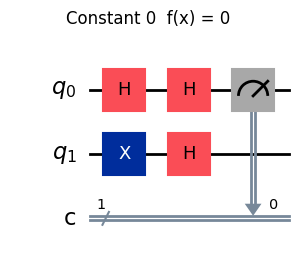

Saved img/deutsch_constant_0.png


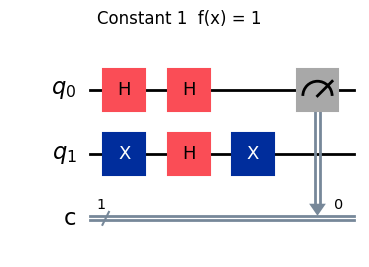

Saved img/deutsch_constant_1.png


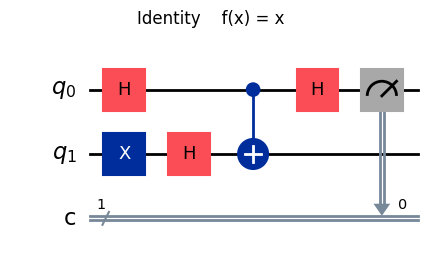

Saved img/deutsch_identity.png


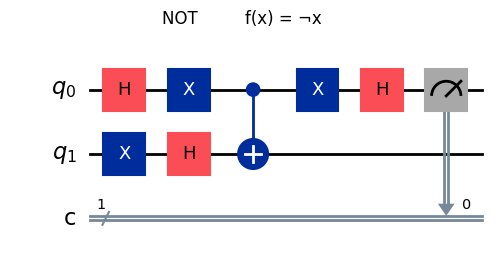

Saved img/deutsch_not.png


In [16]:
oracles_to_draw = [
    (oracle_constant_0, "constant_0", "Constant 0  f(x) = 0"),
    (oracle_constant_1, "constant_1", "Constant 1  f(x) = 1"),
    (oracle_identity,   "identity",   "Identity    f(x) = x"),
    (oracle_not,        "not",         "NOT         f(x) = ¬x"),
]

for oracle_fn, slug, label in oracles_to_draw:
    _, qc = deutsch_algorithm(oracle_fn)
    fig = qc.draw('mpl')
    fig.suptitle(label)
    path = f"img/deutsch_{slug}.png"
    fig.savefig(path, bbox_inches='tight', dpi=150)
    display(fig)
    plt.close(fig)
    print(f"Saved {path}")

### Testing and comparing

We run `deutsch_algorithm` on all four oracles and check the output against the known classification from Problem 3.

| Oracle | $f(0)$ | $f(1)$ | Classification |
|--------|--------|--------|----------------|
| Constant 0 | 0 | 0 | constant |
| Constant 1 | 1 | 1 | constant |
| Identity | 0 | 1 | balanced |
| NOT | 1 | 0 | balanced |

Each oracle is passed into `deutsch_algorithm` exactly once. The function calls the oracle once internally. No other information about the function is used.

In [17]:
test_cases = [
    (oracle_constant_0, "Constant 0  f(x) = 0",  "constant"),
    (oracle_constant_1, "Constant 1  f(x) = 1",  "constant"),
    (oracle_identity,   "Identity    f(x) = x",  "balanced"),
    (oracle_not,        "NOT         f(x) = ¬x", "balanced"),
]

print("Deutsch's Algorithm — Results")
print("=" * 52)

passed = 0

for oracle_fn, label, expected in test_cases:
    result, _ = deutsch_algorithm(oracle_fn)
    correct    = result == expected
    status     = "Pass" if correct else "Fail"

    if correct:
        passed += 1

    print(f"  {status}  {label}")
    print(f"       result: {result}   expected: {expected}")

print("=" * 52)
print(f"  {passed}/{len(test_cases)} correct")

if passed == len(test_cases):
    print("  All oracles correctly classified.")
else:
    print("  Some results were unexpected — review the circuit construction.")

Deutsch's Algorithm — Results
  Pass  Constant 0  f(x) = 0
       result: constant   expected: constant
  Pass  Constant 1  f(x) = 1
       result: constant   expected: constant
  Pass  Identity    f(x) = x
       result: balanced   expected: balanced
  Pass  NOT         f(x) = ¬x
       result: balanced   expected: balanced
  4/4 correct
  All oracles correctly classified.


## Code Explanation

**`deutsch_algorithm(oracle)`:**

A fresh circuit is created for each call to avoid any leftover state from a previous run.

The ancilla qubit $q_1$ is prepared with `qc.x(1)` followed by `qc.h(1)` — order matters here. X first, then H gives us the minus state $|{-}\rangle$. Doing it the other way around would produce the plus state $|{+}\rangle$ instead, which breaks phase kickback and gives wrong results for balanced oracles.

The oracle is called as `oracle(qc, 0, 1)`, which is the only point `f` is queried. It doesn't return a value, it modifies `qc` directly by inserting gates at the end of the circuit. We don't need to know anything about the oracle internally; the measurement result tells us.

`shots=1` is intentional — the algorithm is deterministic, so one run always gives the correct answer.

**Visualisation:**

The circuit diagrams confirm all four circuits share the same outer structure, only the oracle section changes. The constant oracles are visually much simpler (Constant 0 has no gates at all), while the balanced oracles have more going on inside.

**Testing:**

All four oracles produce the expected classification. Since the algorithm is deterministic, repeating the tests would always give the same results.

## Problem 5: Scaling to the Deutsch–Jozsa Algorithm

### Context
The [Deutsch–Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) extends Deutsch's algorithm from 1 input bit to any number, this currently being 4. The goal is still the same: determine whether a function is constant or balanced, but now `f(a, b, c, d)` takes 4 Boolean inputs.

Like Deutsch's algorithm, it does this in a single query using superposition and interference.

| Property | Deutsch | Deutsch–Jozsa (n=4) |
|---|---|---|
| Input qubits | 1 | 4 |
| Ancilla qubit | 1 | 1 |
| Total qubits | 2 | 5 |
| Classical queries (worst case) | 2 | 9 |
| Quantum queries | 1 | 1 |

### Quantum Oracle
A quantum oracle is the quantum equivalent of calling `f(a, b, c, d)`. As quantum gates must be reversible, the function is encoded using the **phase kickback** trick with an ancilla qubit initialised to $|{-}\rangle$.

The oracle applies:

$$|x\rangle|{-}\rangle \xrightarrow{\text{oracle}} (-1)^{f(x)}|x\rangle|{-}\rangle$$

If `f(x) = 1`, the oracle flips the phase of that input state. If `f(x) = 0`, nothing changes. The ancilla itself is unchanged, the effect kicks back into the input qubits.

### Building the Oracle from a Truth Table

For each input where `f` returns `True`:
1. Apply X gates to any input qubit that should be `0` in that pattern
2. Apply a 4-controlled X gate (MCX) targeting the ancilla
3. Undo the X gates

Because the ancilla is in the $|{-}\rangle$ state, the MCX causes a phase flip rather than a visible bit flip.

### `build_dj_oracle(f)`

Takes a classical Boolean function `f` and returns a 5-qubit oracle circuit (qubits 0–3 input, qubit 4 ancilla).

For each of the 16 truth table entries that is `True`, it adds an X-MCX-X gadget to flip the phase of that input state.

In [18]:
def build_dj_oracle(f):
    """
    Build a Deutsch–Jozsa oracle circuit for a 4-input Boolean function.

    Encodes the classical function f(a, b, c, d) as a quantum oracle using
    phase kickback. For every input where f returns True, the oracle flips
    the phase of that input state using the ancilla qubit.

    Args:
        f: A Boolean function from Problem 1, with a truth_table attribute.

    Returns:
        A QuantumCircuit with 5 qubits (0–3 input, 4 ancilla).
    """
    # 4 input qubits + 1 ancilla qubit
    oracle = qiskit.QuantumCircuit(5)

    # Iterate through all 16 possible input combinations
    for index in range(16):

        # Only add gates for inputs where f returns True
        if f.truth_table[index]:

            # Convert the index back into 4 individual bits
            # Each bit tells us the value of one input qubit
            bits = [(index >> (3 - i)) & 1 for i in range(4)]

            # Flip any input qubit that should be 0 in this pattern
            # This lets the MCX gate trigger on that specific input combination
            for qubit, bit in enumerate(bits):
                if bit == 0:
                    oracle.x(qubit)

            # Apply a 4-controlled X gate targeting the ancilla (qubit 4)
            # This triggers only when qubits 0–3 all equal 1
            oracle.mcx([0, 1, 2, 3], 4)

            # Undo the X gates to restore those input qubits
            for qubit, bit in enumerate(bits):
                if bit == 0:
                    oracle.x(qubit)

    return oracle

### Code Explanation

We loop through all 16 input indices. For each one where `f` returns `True`, we add an X-MCX-X gadget.

The X gates before the MCX flip any qubit that should be `0`, so that all four input qubits are `1` for that specific pattern, allowing the MCX to fire. The X gates after undo that change.

Since the ancilla is in $|{-}\rangle$, the MCX causes a phase kickback instead of a visible flip, stamping a minus sign onto that input state.

- **Constant-0**: truth table is all `False`, so no gates are added — the oracle is empty.
- **Constant-1**: truth table is all `True`, so all 16 gadgets are added.

### Deutsch–Jozsa Circuit

The full circuit wraps the oracle in the standard structure:

1. Initialise 4 input qubits to $|0\rangle$ (default)
2. Set ancilla (qubit 4) to $|1\rangle$ with an X gate
3. Apply H to all 5 qubits: inputs enter superposition, ancilla enters $|{-}\rangle$
4. Apply the oracle
5. Apply H to the 4 input qubits only
6. Measure the 4 input qubits

| Measurement | Result |
|---|---|
| `0000` | Constant |
| Anything else | Balanced |

For a constant function, the phases are uniform across all inputs, so the final H gates cause all probability to constructively interfere back to `0000`. For a balanced function, the phases cancel at `0000`, probability lands elsewhere.

### `deutsch_jozsa(oracle)`

Takes an oracle circuit and returns the classification (`"constant"` or `"balanced"`) and the full assembled circuit.

In [19]:
def deutsch_jozsa(oracle):
    """
    Run the Deutsch–Jozsa algorithm on a 4-input quantum oracle.

    Builds and simulates the full Deutsch–Jozsa circuit, then reads the
    measurement outcome to determine whether the function is constant or
    balanced.

    Args:
        oracle: A QuantumCircuit with 5 qubits returned by build_dj_oracle.

    Returns:
        A tuple (result, circuit) where result is "constant" or "balanced"
        and circuit is the full assembled QuantumCircuit.
    """
    # 4 input qubits + 1 ancilla, and 4 classical bits to record the measurement
    qc = qiskit.QuantumCircuit(5, 4)

    # Initialisation
    # Set ancilla qubit (qubit 4) to |1⟩
    qc.x(4)

    # Apply Hadamard to all 5 qubits
    # Input qubits enter equal superposition; ancilla enters the |−⟩ state
    qc.h([0, 1, 2, 3, 4])

    # Oracle
    # Append the oracle circuit to the main circuit
    qc.compose(oracle, inplace=True)

    # Interference
    # Apply Hadamard to the 4 input qubits only (not the ancilla)
    qc.h([0, 1, 2, 3])

    # Measurement
    # Measure the 4 input qubits into the 4 classical bits
    qc.measure([0, 1, 2, 3], [0, 1, 2, 3])

    # Simulation
    backend  = aer.Aer.get_backend("qasm_simulator")
    compiled = qiskit.transpile(qc, backend)
    counts   = backend.run(compiled, shots=1).result().get_counts()

    # Classification
    # The algorithm is deterministic — one shot is enough
    # '0000' → constant, anything else → balanced
    outcome = list(counts.keys())[0]

    result = "constant" if outcome == "0000" else "balanced"

    return result, qc

### Code Explanation

The circuit has 5 qubits and 4 classical bits. The ancilla is set to $|1\rangle$ with an X gate, then all five qubits get a Hadamard, putting the inputs into superposition and the ancilla into $|{-}\rangle$.

The oracle is inserted with `qc.compose(oracle, inplace=True)`, applying phase kickback for each input where `f` returns `True`.

After the oracle, H is applied to the 4 input qubits to cause interference. A constant function concentrates all probability at `0000`, a balanced function cancels it there.

We use `shots=1` since the result is deterministic.

### Testing
We test the algorithm on four functions:
- **Constant-0**: always returns `False`
- **Constant-1**: always returns `True`
- **Two balanced functions**: randomly generated using `random_constant_balanced` from Problem 1

For each, we build the oracle, run the circuit, and check the result against the known type.

In [20]:
# Build the two constant functions manually

# Constant-0: always returns False
def constant_0(a, b, c, d):
    return False

constant_0.truth_table = [False] * 16
constant_0.is_constant = True

# Constant-1: always returns True
def constant_1(a, b, c, d):
    return True

constant_1.truth_table = [True] * 16
constant_1.is_constant = True

# Generate two random balanced functions from Problem 1

# Keep generating until we have two balanced ones
balanced_functions = []

while len(balanced_functions) < 2:
    f = random_constant_balanced()
    if not f.is_constant:
        balanced_functions.append(f)

balanced_0, balanced_1 = balanced_functions

print("Functions ready:")
print("  constant_0  — truth table:", constant_0.truth_table)
print("  constant_1  — truth table:", constant_1.truth_table)
print("  balanced_0  — truth table:", balanced_0.truth_table)
print("  balanced_1  — truth table:", balanced_1.truth_table)

Functions ready:
  constant_0  — truth table: [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]
  constant_1  — truth table: [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]
  balanced_0  — truth table: [False, True, False, True, True, True, True, False, False, False, False, True, True, True, False, False]
  balanced_1  — truth table: [True, False, False, True, False, True, True, False, True, True, False, False, False, False, True, True]


In [21]:
# Run the Deutsch–Jozsa algorithm on all four functions

test_cases = [
    (constant_0, "constant", "Constant-0"),
    (constant_1, "constant", "Constant-1"),
    (balanced_0, "balanced", "Balanced-0"),
    (balanced_1, "balanced", "Balanced-1"),
]

print("Deutsch–Jozsa Algorithm — Results")
print("=" * 52)

passed = 0

for f, expected, label in test_cases:
    oracle  = build_dj_oracle(f)
    result, _ = deutsch_jozsa(oracle)
    correct = result == expected
    status  = "Pass" if correct else "Fail"

    if correct:
        passed += 1

    print(f"  {status}  {label}")
    print(f"       result: {result}   expected: {expected}")

print("=" * 52)
print(f"  {passed}/{len(test_cases)} correct")

if passed == len(test_cases):
    print("All functions correctly classified.")
else:
    print("Some results were unexpected — review the oracle construction.")

Deutsch–Jozsa Algorithm — Results
  Pass  Constant-0
       result: constant   expected: constant
  Pass  Constant-1
       result: constant   expected: constant
  Pass  Balanced-0
       result: balanced   expected: balanced
  Pass  Balanced-1
       result: balanced   expected: balanced
  4/4 correct
All functions correctly classified.


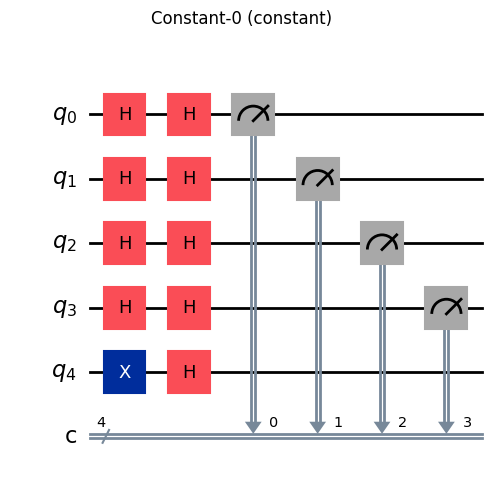

Saved img/dj_constant_0.png


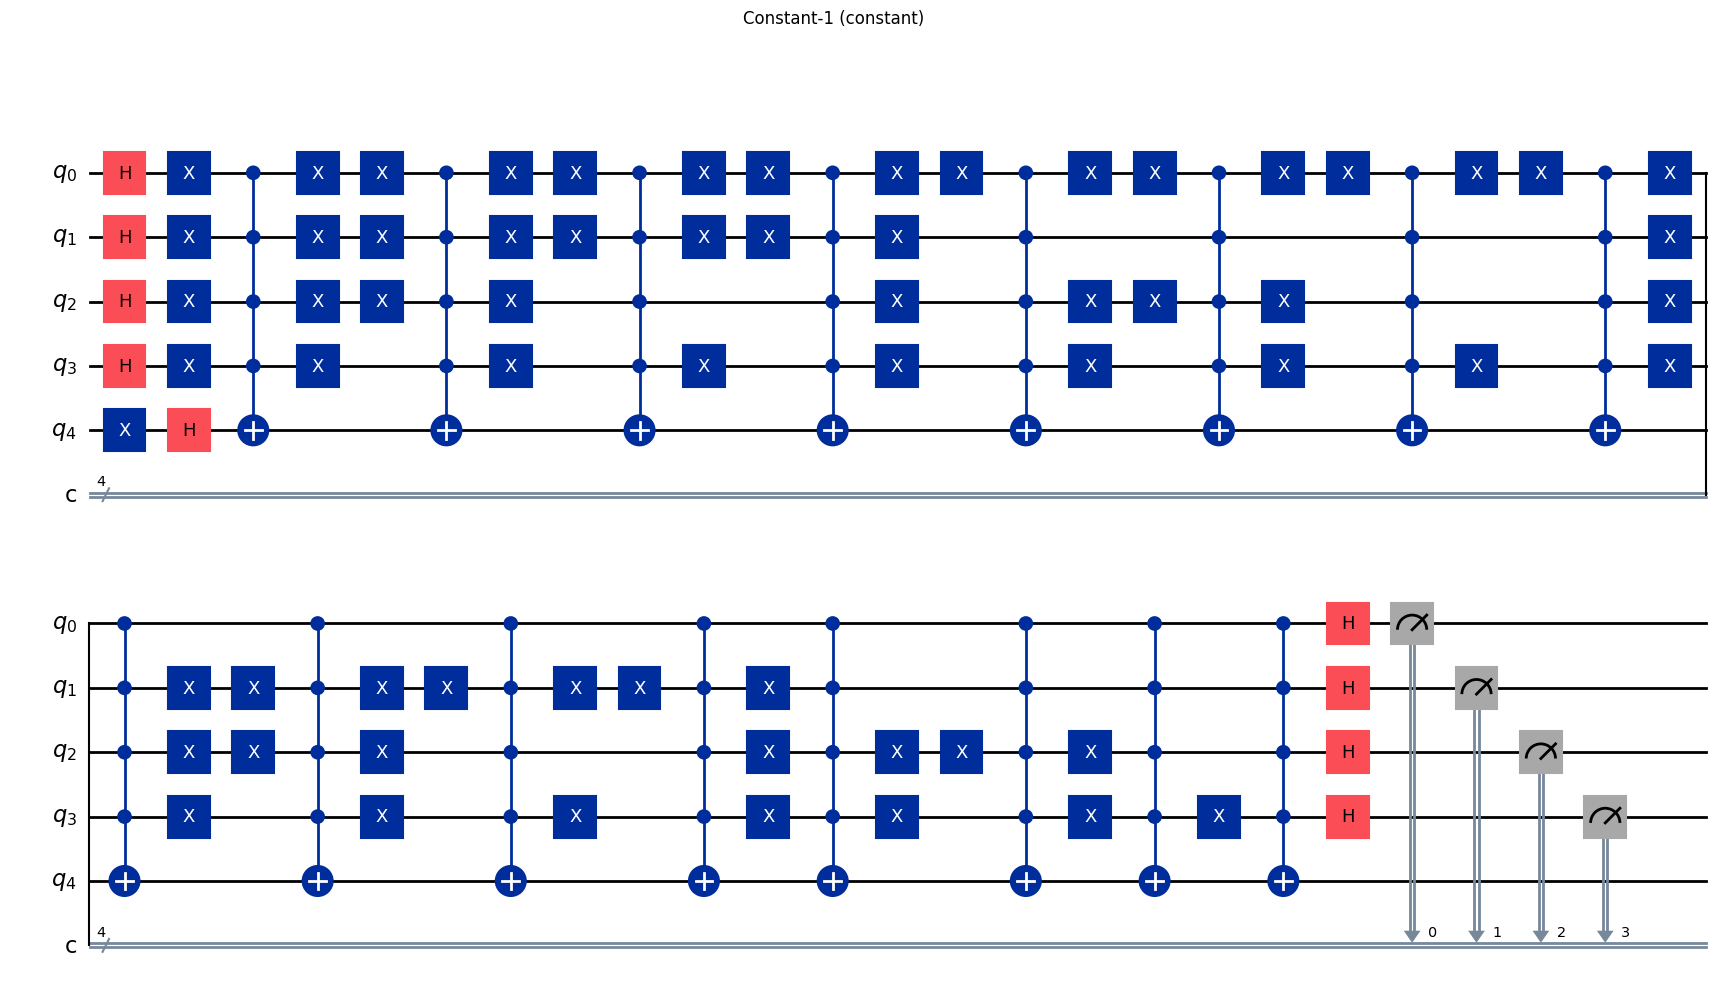

Saved img/dj_constant_1.png


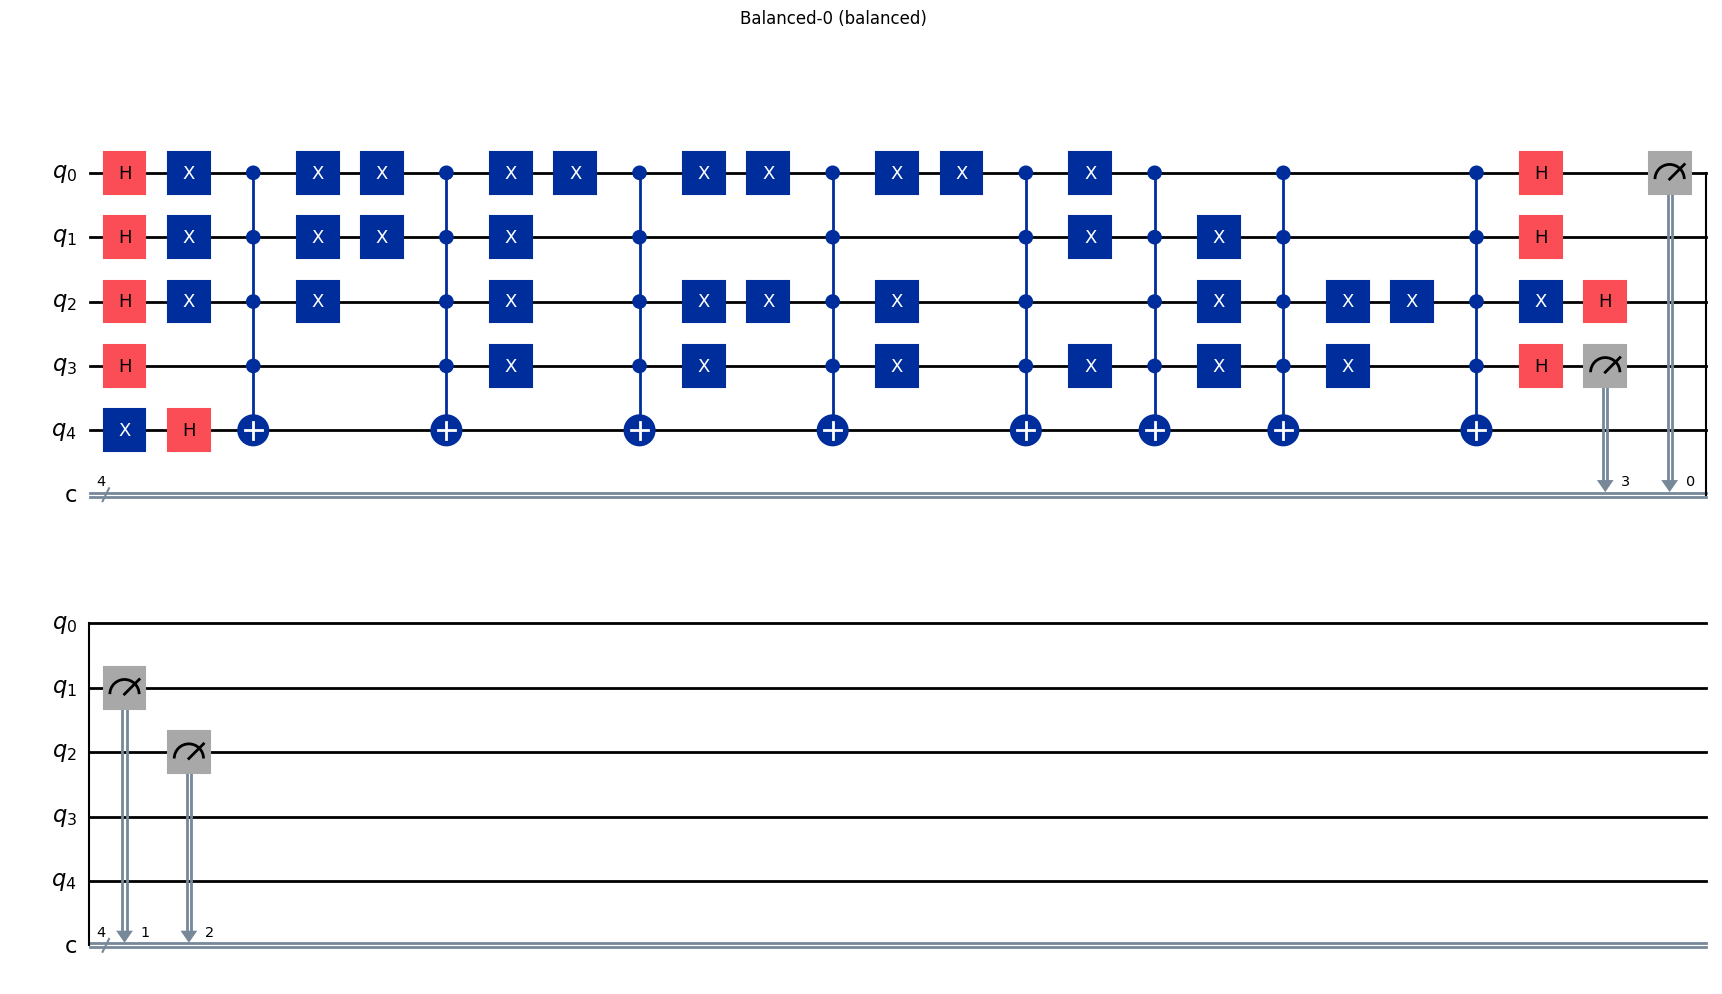

Saved img/dj_balanced_0.png


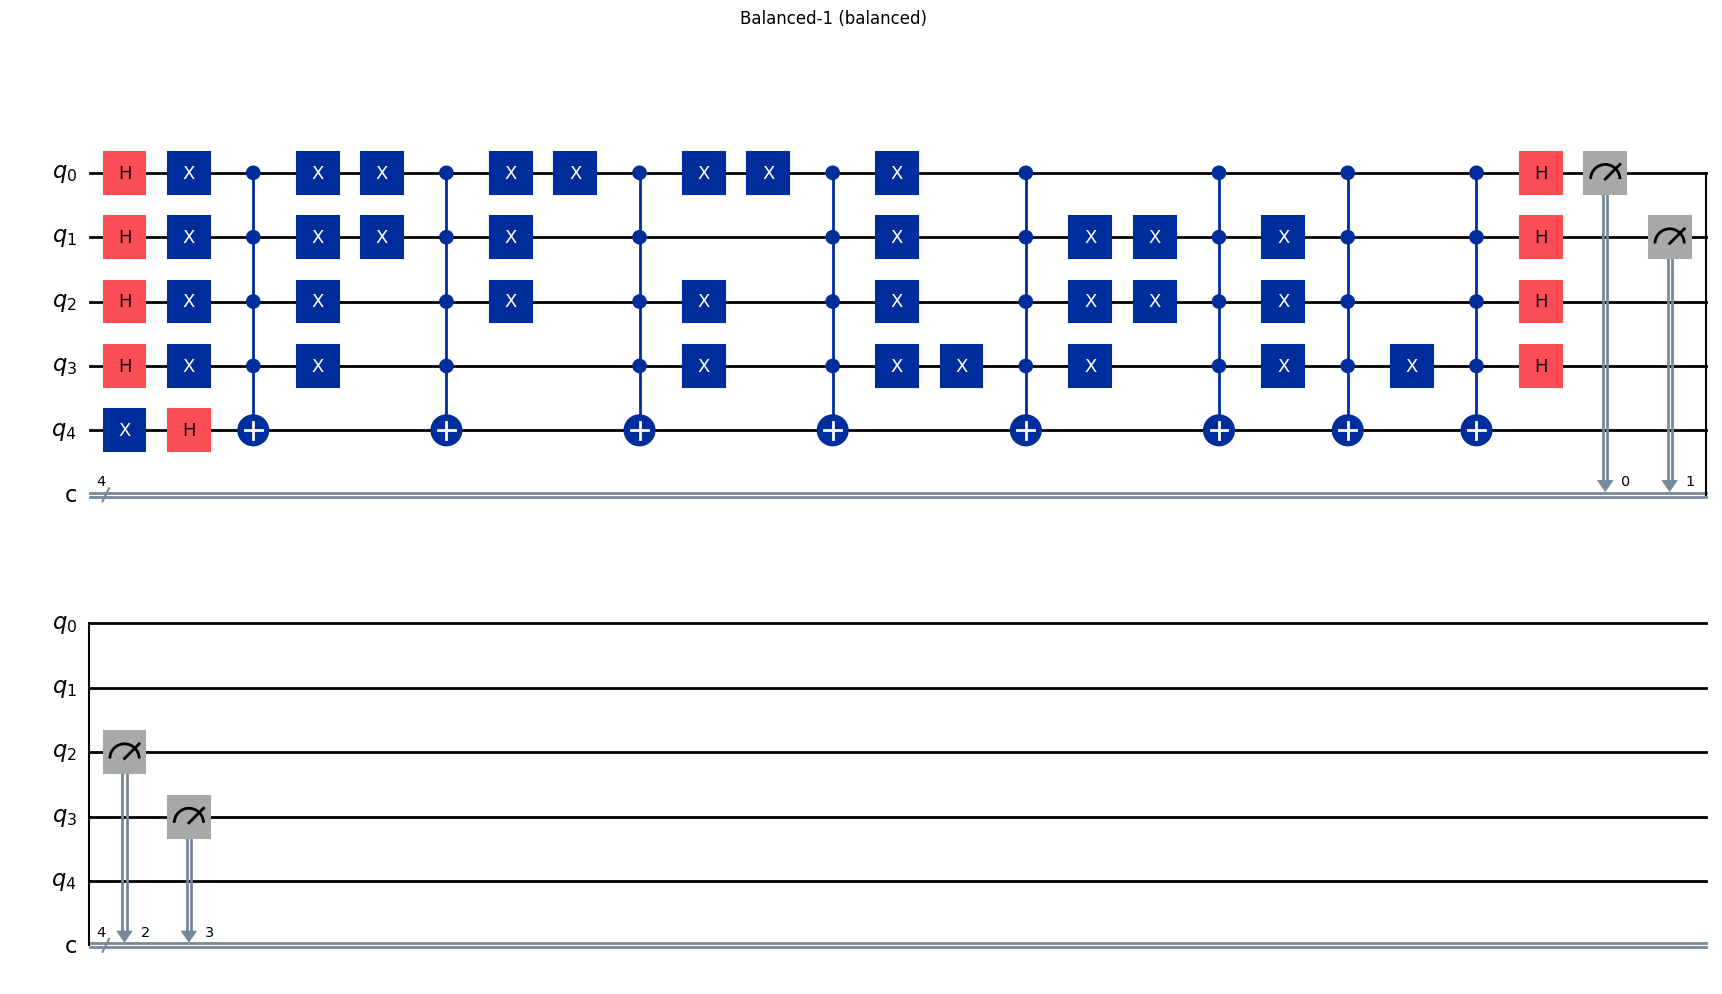

Saved img/dj_balanced_1.png


In [22]:
# Save and display a circuit diagram for each test case

for f, expected, label in test_cases:
    oracle = build_dj_oracle(f)
    _, qc  = deutsch_jozsa(oracle)
    slug = label.lower().replace(" ", "_").replace("-", "_")
    fig = qc.draw('mpl')
    fig.suptitle(f"{label} ({expected})")
    path = f"img/dj_{slug}.png"
    fig.savefig(path, bbox_inches='tight', dpi=150)
    display(fig)
    plt.close(fig)
    print(f"Saved {path}")

### Code Explanation

The two constant functions are built manually so we have exactly one constant-0 and one constant-1, using the same `truth_table` and `is_constant` attributes as `random_constant_balanced` so `build_dj_oracle` works without changes.

The balanced functions are pulled from `random_constant_balanced` until we have two that are balanced.

The test loop builds and runs the oracle for each function, compares the result to the known type, and prints pass/fail. The circuit diagrams show how the oracle grows with the truth table, constant-0 has no gates, constant-1 has 16 gadgets, and each balanced function has 8.

### Summary

After the initial H gates, the input register is in an equal superposition of all 16 states. The oracle stamps a minus sign onto every state where `f` returns `True`.

- **Constant**: either all states get a minus sign or none do, the pattern is uniform.
- **Balanced**: exactly half get a minus sign, the pattern is split.

The final H gates turn this phase pattern into a probability pattern. A uniform phase (constant) causes all probability to constructively interfere at `0000`. A split phase (balanced) causes perfect destructive interference at `0000`, so probability lands elsewhere.

### Quantum vs Classical

| Approach | Queries needed (worst case, n=4) |
|---|---|
| Classical (Problem 2) | 9 |
| Deutsch–Jozsa | 1 |

Classically, $2^{n-1} + 1$ queries are needed for an $n$-bit function. The quantum algorithm always uses exactly 1.

## References

- [Deutsch–Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) — IBM Quantum Learning. The primary reference for the algorithm addressed in Problems 1 and 5. Used to understand how a single quantum query determines whether a multi-input function is constant or balanced, and how the circuit scales from 1 input bit to 4.

- [Deutsch's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) — IBM Quantum Learning. The single-input case implemented in Problems 3 and 4. Provides the mathematical basis for the oracle transformation $|x,y\rangle \rightarrow |x, y \oplus f(x)\rangle$ and explains how phase kickback and interference produce a deterministic measurement result from a single oracle call.

- [Quantum oracles](https://quantumcomputing.stackexchange.com/a/4626) — Quantum Computing Stack Exchange. Explains the oracle model used in Problems 3, 4, and 5, specifically why functions must be encoded as reversible unitary operations, and how the ancilla qubit acts as a target for the XOR transformation without overwriting the input register.

- [Concepts of quantum oracles](https://learn.microsoft.com/en-us/azure/quantum/concepts-oracles) — Microsoft Azure Quantum. Reference for the reversibility requirement applied throughout Problems 3 and 5. Explains why classical Boolean logic cannot be applied directly to quantum states and how phase and marking oracles differ in construction.

- [Quantum oracle design](https://syskool.com/quantum-oracle-design/) — SysKool. Supplementary reference for the gate-level construction of oracles used in Problems 3 and 5, particularly the X-MCX-X gadget pattern used in `build_dj_oracle` to trigger phase kickback selectively for each truth table entry.

- [Quantum oracles and phase kickback](https://docs.classiq.io/explore/tutorials/workshops/oracle_workshop/oracles_workshop#quantum-oracles-and-arithmetics-phase-kickback) — Classiq. Explains the phase kickback mechanism used in Problem 5, where the ancilla is initialised to $|{-}\rangle$ so that a controlled-X causes a phase flip rather than a visible bit flip, stamping $(-1)^{f(x)}$ onto each input state.

- [Quantum oracles — introductory circuits](https://quantum-education-modules.readthedocs.io/en/latest/introductory/circuits/oracles.html) — Quantum Education Modules. A readable walkthrough of oracle construction used alongside the formal references when building and verifying the four single-input oracles in Problem 3.

- [What is a quantum oracle?](https://milvus.io/ai-quick-reference/what-is-a-quantum-oracle-and-how-is-it-used-in-algorithms-like-grovers-search) — Milvus AI Quick Reference. Background on the black-box oracle model referenced in Problem 3, where the algorithm is only permitted to query $U_f$ and the number of queries is the key metric for comparing quantum and classical complexity.

- [Quantum superposition](https://scienceexchange.caltech.edu/topics/quantum-science-explained/quantum-superposition) — Caltech Science Exchange. Explains the superposition principle behind the equal superposition of all 16 input states after the initial Hadamard gates in Problem 5, allowing the oracle to evaluate $f$ on all inputs simultaneously in a single query.

- [Quantum entanglement — global properties](https://plato.stanford.edu/archives/fall2008/entries/qt-entangle/#5) — Stanford Encyclopedia of Philosophy. Used in Problem 3 to contextualise why Deutsch's algorithm determines a **global property** of the function (constant or balanced) from a single evaluation, rather than inspecting individual input-output pairs.

- [Reversible computation and group theory in quantum computing](https://www.ibm.com/quantum/blog/group-theory) — IBM Quantum. Background on why quantum gates must be unitary and reversible, referenced in Problems 3 and 5 to justify the oracle design, particularly why the NOT oracle must restore the input qubit with a second X gate, and why classical irreversible logic gates cannot be used directly.

- [Quantum circuits](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/quantum-circuits/circuits) — IBM Quantum Learning. Reference for the quantum circuit model used throughout Problems 3, 4, and 5 when constructing, composing, and drawing circuits in Qiskit.

- [Pigeonhole principle](https://en.wikipedia.org/wiki/Pigeonhole_principle) — Wikipedia. The combinatorial argument used in Problem 2 to establish that a classical algorithm needs at most 9 queries (not 16) to determine with certainty whether a 4-input function is constant or balanced.

- [Quantum advantage and supremacy](https://www.quantamagazine.org/john-preskill-explains-quantum-supremacy-20191002/) — Quanta Magazine. Cited in Problem 2 to motivate the efficiency analysis — understanding the classical worst-case cost of 9 queries is what makes the quantum algorithm's single-query solution meaningful.

- [Deutsch–Jozsa algorithm](https://en.wikipedia.org/wiki/Deutsch%E2%80%93Jozsa_algorithm) — Wikipedia. Used as a general reference for the algorithm's history, circuit structure, and correctness proof across Problems 1 and 5.

- [Quantum Information and Computation](https://www.qi.damtp.cam.ac.uk/files/QIC-9.pdf) — University of Cambridge. Used in Problem 1 to establish the exact count of $\binom{16}{8} = 12{,}870$ balanced functions for 4-input Boolean functions, which informs the design of `random_constant_balanced`.

- [Boolean functions in Python](https://realpython.com/python-boolean/) — Real Python. Reference for Python's Boolean type and operations used in Problems 1 and 2, including the `True`/`False` inputs, truth table construction, and the `count` method used for classification.

- [Unitary matrix](https://en.wikipedia.org/wiki/Unitary_matrix) — Wikipedia. Mathematical reference for the class of operations that quantum gates must implement, cited in Problem 3 when describing how oracles encode classical Boolean functions as reversible quantum operations.

- [MCXGate](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.MCXGate) — IBM Quantum API Reference. The multi-controlled X gate used in `build_dj_oracle` in Problem 5 to implement the 4-controlled phase flip for each truth table entry where `f` returns `True`.

## Conclusion

This notebook demonstrates the Deutsch–Jozsa algorithm from the ground up, progressing through five interconnected problems.

It begins by generating 4-input Boolean functions that are guaranteed to be either constant or balanced (Problem 1). We then showed that a classical algorithm must make up to **9 queries** in the worst case to distinguish the two types (Problem 2). Problems 3 and 4 introduced the quantum building blocks, phase-kickback oracles and Deutsch's single-qubit algorithm, before Problem 5 assembled everything into the full Deutsch–Jozsa circuit, which solves the same problem with exactly **1 query**.

The exponential gap (9 vs 1 for $n = 4$; generally $2^{n-1}+1$ vs 1) is one of the earliest and cleanest proofs that quantum computers can solve certain problems fundamentally faster than any classical algorithm. While the Deutsch–Jozsa problem is somewhat artificial, the techniques at its core: superposition, oracle queries, and interference, underpin practical quantum algorithms such as Grover's search and Shor's factoring algorithm.

Quantum computing remains an active research area, it represents a genuinely different and more powerful way of processing information for the right class of problems.

***
# End